# 04 · Preprocesamiento — Única Etapa de Transformación
**Tesis:** Medición del ciclo financiero en Perú
**Autor:** Roberto Samaniego | **Asesor:** Dr. Sergio Camiz

---

**Responsabilidad única de este notebook:** aplicar, de forma explícita y
documentada, las transformaciones necesarias para dejar el dataset listo para
PCA/HFC. Es el **único** lugar del pipeline donde el dato cambia de forma —
por eso conviene que tu asesor revise específicamente este notebook.

**Entrada:** `data/raw/series_bcrp_raw.csv` (inmutable, generado en `01_extraccion_bcrp.ipynb`)
**Salida:** cuatro versiones en `data/processed/`, cada una con su propósito documentado:
1. `dataset_niveles_trimestral.csv` — niveles, solo sincronizado a trimestral
2. `dataset_niveles_estandarizado_trimestral.csv` — niveles + estandarización (SIN log-diff/diff)
3. `dataset_transformado_trimestral.csv` — estacionario (log-diff / diff), sin estandarizar
4. `dataset_estandarizado_trimestral.csv` — transformado + estandarizado, listo para PCA/HFC

Las versiones (2) y (4) permiten correr PCA/HFC en ambos enfoques bajo
igualdad de condiciones (ambas estandarizadas), difiriendo solo en si las
series están o no diferenciadas -- ver la discusión metodológica sobre
niveles vs. diferencias vs. brechas antes de interpretar resultados.

Guardar las cuatro versiones (y no solo la última) permite auditar cada
paso por separado y comparar resultados de PCA/HFC entre enfoques.

## 1. Librerías y carga del dato crudo (solo lectura)

In [1]:
import os
os.chdir('..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

df_raw = pd.read_csv('data/raw/series_bcrp_raw.csv', index_col=0, parse_dates=True)
print(f'Dataset crudo cargado (solo lectura): {df_raw.shape[0]} filas x {df_raw.shape[1]} columnas')

Dataset crudo cargado (solo lectura): 228 filas x 18 columnas


## 2. Carga de series con frecuencia distinta a la mensual (trimestral/diaria)

Estas series ya vienen en otra frecuencia y se cargan desde su propio archivo
crudo en `data/raw/`, sin modificar esos archivos tampoco:
- Índice de precios de inmuebles: trimestral.
- EMBI Perú: diario (se sincroniza a trimestral en este mismo notebook,
  igual criterio de promedio del periodo que el resto de series).

In [2]:
ruta_inmuebles = 'data/raw/indice_precios_inmuebles_bcrp.csv'
if os.path.exists(ruta_inmuebles):
    df_inmuebles = pd.read_csv(ruta_inmuebles, parse_dates=['fecha']).set_index('fecha')
    df_inmuebles = df_inmuebles[['indice_precios_inmuebles']]
    print(f'Índice de inmuebles: {df_inmuebles.shape[0]} observaciones trimestrales')
else:
    df_inmuebles = None
    print(f'⚠ No se encontró {ruta_inmuebles}; continuar sin esta serie o agregarla a data/raw/')

ruta_embi = 'data/raw/embi_peru_raw.csv'
if os.path.exists(ruta_embi):
    df_embi_diario = pd.read_csv(ruta_embi, index_col=0, parse_dates=True)
    # EMBI es diario -> se sincroniza a trimestral aqui, mismo criterio (promedio
    # del periodo) que se usa para el resto de series mensuales en la celda siguiente.
    df_embi = df_embi_diario.resample('QE').mean()
    df_embi.index = df_embi.index.to_period('Q').to_timestamp('Q')
    print(f'EMBI Perú (resampleado a trimestral): {df_embi.shape[0]} observaciones')
else:
    df_embi = None
    print(f'⚠ No se encontró {ruta_embi}; continuar sin esta serie o agregarla a data/raw/')

Índice de inmuebles: 73 observaciones trimestrales
EMBI Perú (resampleado a trimestral): 92 observaciones


## 3. Sincronización a frecuencia trimestral

Convertimos las series mensuales a trimestrales usando el promedio del periodo
(estándar en la literatura de ciclo financiero — Drehmann et al., 2012).
Esta es la primera transformación explícita del pipeline.

In [3]:
df_trimestral = df_raw.resample('QE').mean()
df_trimestral.index = df_trimestral.index.to_period('Q').to_timestamp('Q')

df_completo = df_trimestral
if df_inmuebles is not None:
    df_inmuebles.index = df_inmuebles.index.to_period('Q').to_timestamp('Q')
    df_completo = df_completo.join(df_inmuebles, how='inner')
if df_embi is not None:
    df_completo = df_completo.join(df_embi, how='inner')

print(f'Dataset trimestral sincronizado: {df_completo.shape[0]} filas x {df_completo.shape[1]} columnas')
print(f'Periodo: {df_completo.index.min().strftime("%Y-Q")} a {df_completo.index.max().strftime("%Y-Q")}')
df_completo.tail()

Dataset trimestral sincronizado: 73 filas x 20 columnas
Periodo: 2007-Q a 2025-Q


,Crédito SF sector privado,Crédito empresarial,Crédito consumo,Crédito hipotecario,Tasa activa TAMN,Tasa pasiva TIPMN,Tasa referencia BCRP,Tipo de cambio,Índice BVL,IPC Lima,PBI desestacionalizado,Demanda interna,Reservas internacionales,Liquidez M1,Liquidez M2,Liquidez M3,Tasa interbancaria,IPC Subyacente,indice_precios_inmuebles,embi_peru
fecha,,,,,,,,,,,,,,,,,,,,
2024-12-31,460394.701617,237633.598836,100069.529867,69335.483733,14.801200,2.501567,5.083333,3.755779,29638.906667,114.055972,186.271537,214.531034,81841.171646,155514.941238,494303.843763,674532.616931,5.087533,113.847693,109.7,154.590909
2025-03-31,456774.093152,236778.252658,101058.649467,70297.486800,14.887933,2.350667,4.750000,3.699348,29206.940000,114.517122,186.670088,195.753208,82090.952732,154545.909113,494621.336122,677571.334708,4.743567,114.604151,110.3,159.296875
2025-06-30,462485.215621,241704.343499,102568.723467,71630.534667,14.964433,2.275700,4.583333,3.654583,31382.773333,115.578304,188.196300,211.308791,85230.055379,153630.814037,497235.017914,679733.838136,4.579798,115.601456,112.1,163.369231
2025-09-30,469614.044593,246599.228130,104730.239200,72794.733733,15.181400,2.144900,4.416667,3.534073,35477.593333,115.703282,191.068370,214.534013,86793.687681,159823.459467,516742.454201,704258.295744,4.458800,116.014400,113.9,137.181818
2025-12-31,474703.664297,249912.263617,107341.334133,74318.780000,15.730100,2.065467,4.250000,3.384559,40347.526667,115.663913,192.125609,224.921388,90357.811041,170904.626269,537215.438322,724148.631989,4.246300,116.261363,116.4,125.318182


## 4. Revisión y tratamiento de valores faltantes

In [4]:
nulos = df_completo.isna().sum()
pct_nulos = (nulos / len(df_completo) * 100).round(1)
print(pd.DataFrame({'Nulos': nulos, 'Nulos %': pct_nulos}))

# Se eliminan filas con cualquier nulo para el análisis multivariado (PCA/HFC
# requieren matriz completa). Esta decisión queda documentada aquí, no oculta
# en el notebook de extracción.
df_limpio = df_completo.dropna()
print(f'\nDataset limpio (sin nulos): {df_limpio.shape[0]} filas x {df_limpio.shape[1]} columnas')
print(f'Periodo final: {df_limpio.index.min().strftime("%Y-Q")} a {df_limpio.index.max().strftime("%Y-Q")}')

                           Nulos  Nulos %
Crédito SF sector privado      0      0.0
Crédito empresarial            0      0.0
Crédito consumo                0      0.0
Crédito hipotecario            0      0.0
Tasa activa TAMN               0      0.0
Tasa pasiva TIPMN              0      0.0
Tasa referencia BCRP           0      0.0
Tipo de cambio                 0      0.0
Índice BVL                     0      0.0
IPC Lima                       0      0.0
PBI desestacionalizado         0      0.0
Demanda interna                0      0.0
Reservas internacionales       0      0.0
Liquidez M1                    0      0.0
Liquidez M2                    0      0.0
Liquidez M3                    0      0.0
Tasa interbancaria             0      0.0
IPC Subyacente                 0      0.0
indice_precios_inmuebles       0      0.0
embi_peru                      0      0.0

Dataset limpio (sin nulos): 73 filas x 20 columnas
Periodo final: 2007-Q a 2025-Q


## 4b. Estandarización de niveles (SIN transformar) — para comparación

Se genera una segunda versión estandarizada, pero a partir de los
**niveles originales** (`df_limpio`), sin logaritmo ni diferenciación.

**Propósito:** permitir correr PCA/HFC sobre niveles y sobre la versión
transformada bajo condiciones comparables (ambas estandarizadas), y
contrastar los resultados de ambos enfoques -- ver la discusión
metodológica sobre niveles vs. diferencias en el marco conceptual.

**Advertencia reconocida (no oculta):** si las variables de nivel
comparten una tendencia de crecimiento común en 2003-2025, el primer
componente del PCA sobre esta versión puede capturar en buena parte esa
tendencia compartida, en lugar de una estructura de co-movimiento más
fina. Esto debe evaluarse explícitamente al interpretar los resultados
(por ejemplo, revisando si PC1 correlaciona fuertemente con una tendencia
temporal simple).

Verificación — media ≈ 0, varianza ≈ 1 (niveles estandarizados, sin transformar):
Gráfico guardado


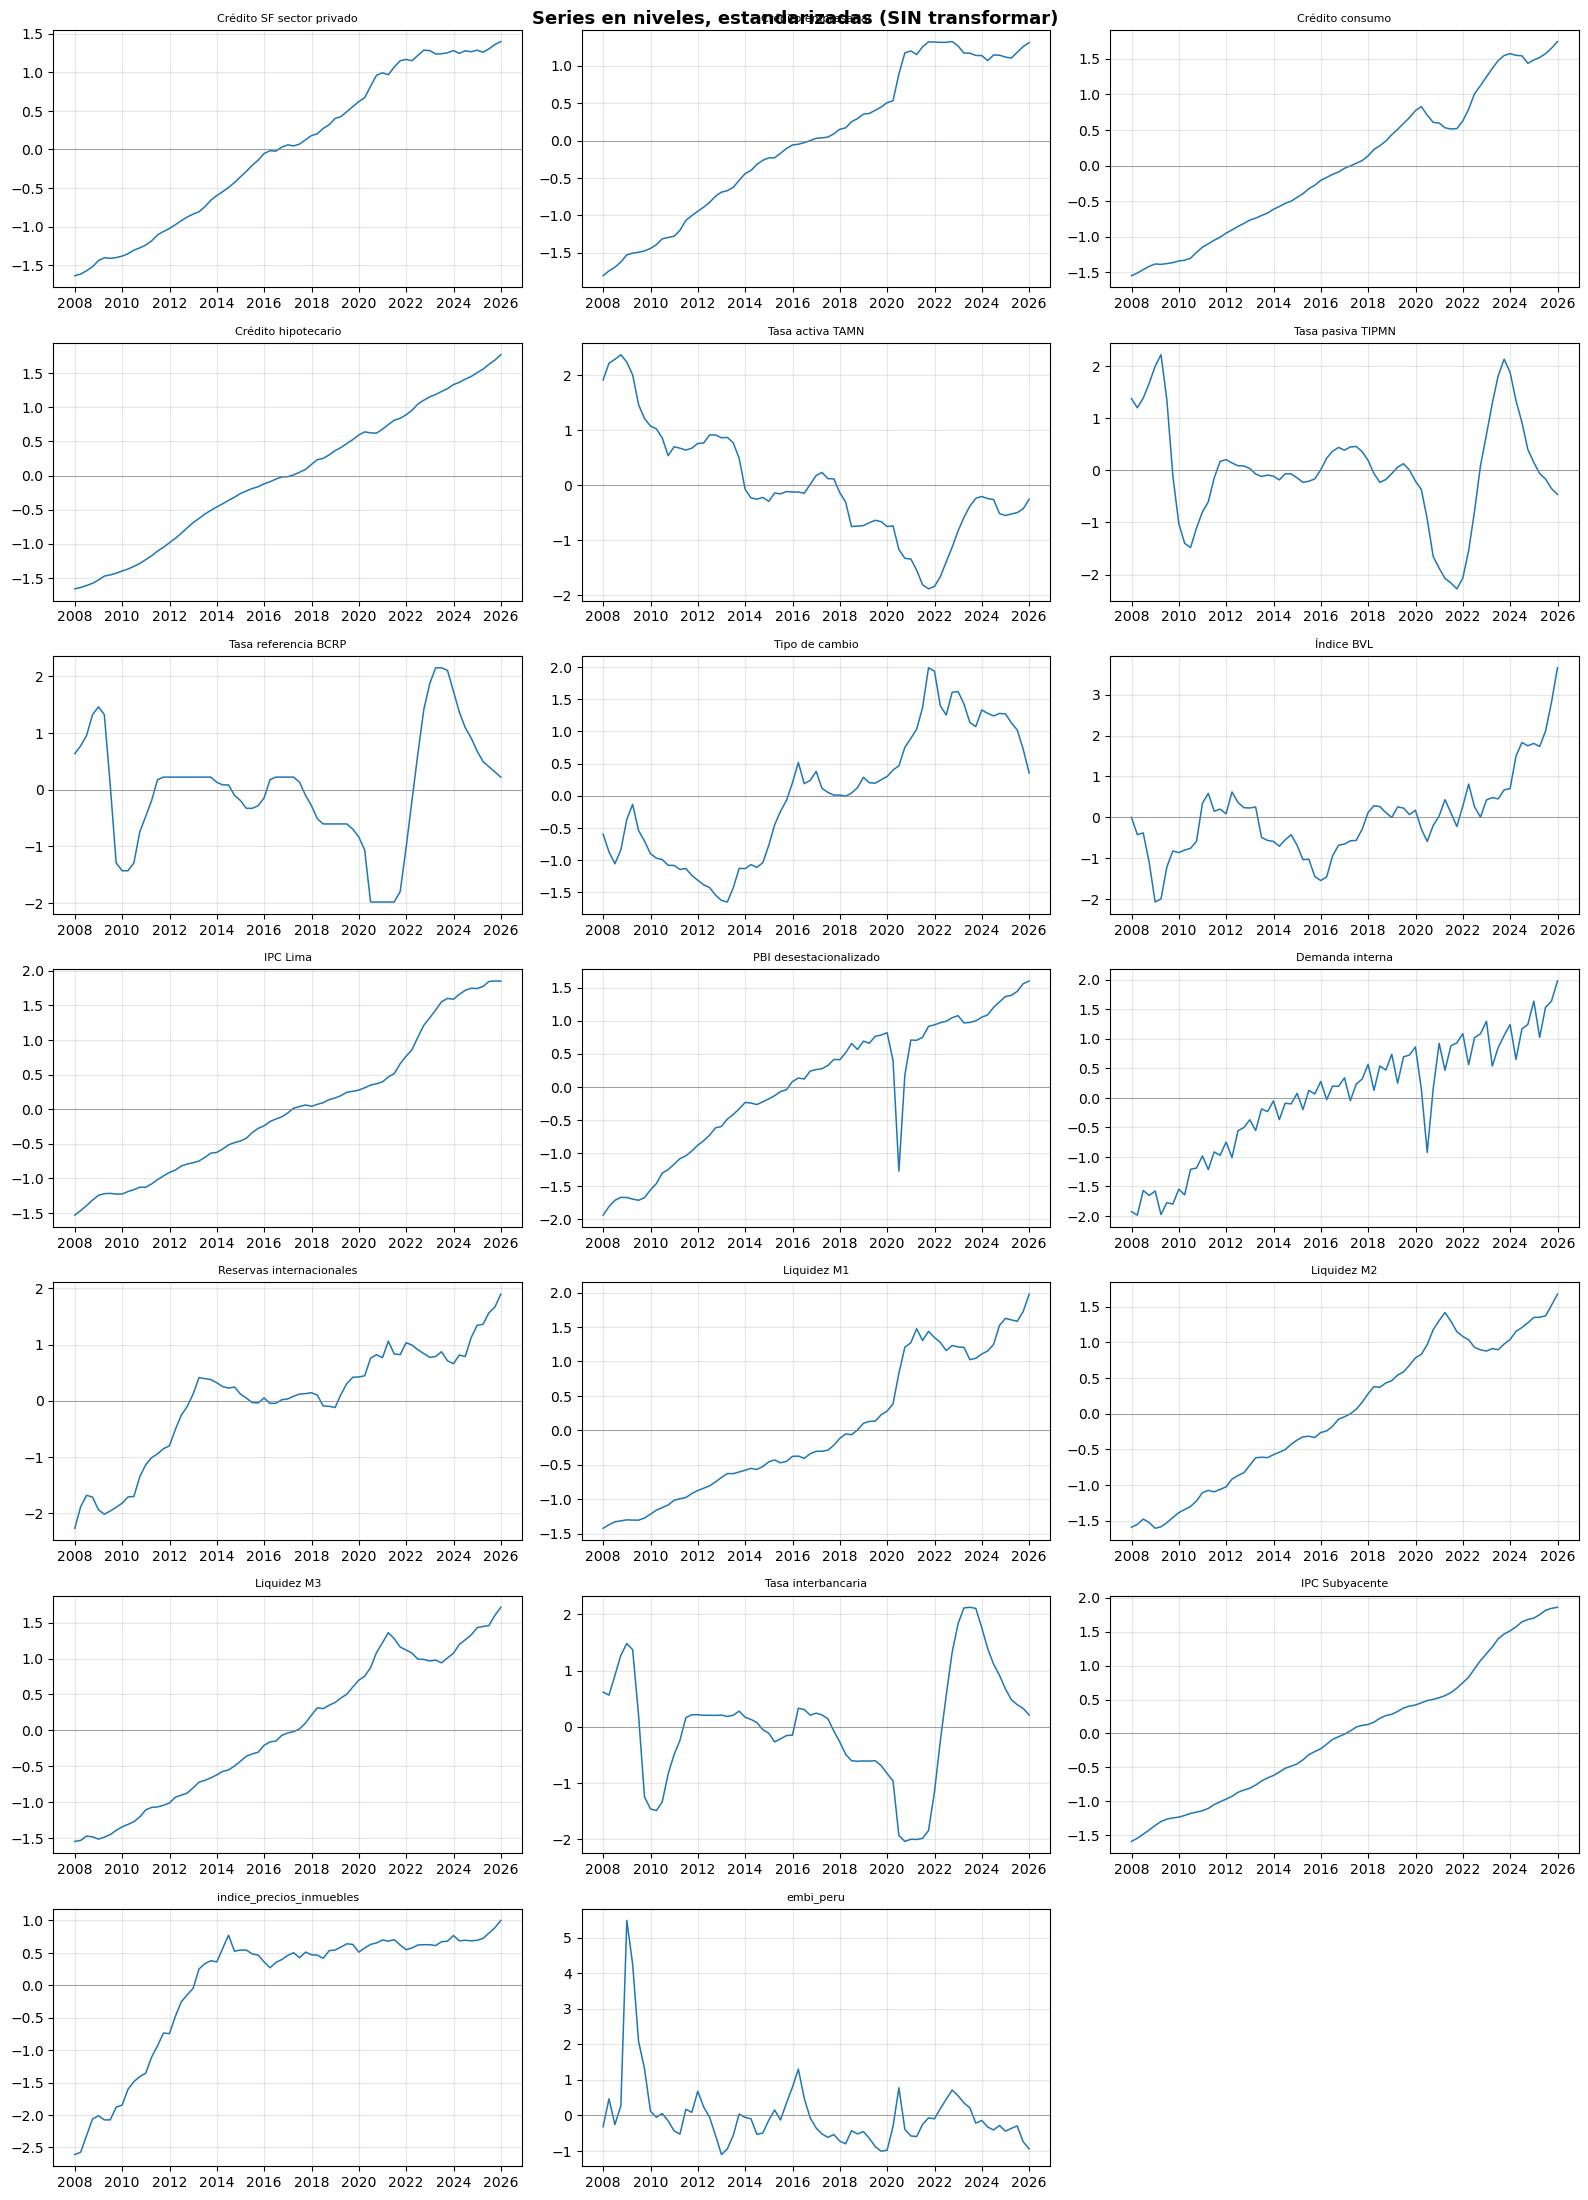

In [5]:
from sklearn.preprocessing import StandardScaler

scaler_niveles = StandardScaler()
df_niveles_estandarizado = pd.DataFrame(
    scaler_niveles.fit_transform(df_limpio),
    index=df_limpio.index,
    columns=df_limpio.columns
)
print('Verificación — media ≈ 0, varianza ≈ 1 (niveles estandarizados, sin transformar):')
df_niveles_estandarizado.describe().loc[['mean', 'std']].round(3)

n_vars = len(df_niveles_estandarizado.columns)
n_cols = 3
n_rows = int(np.ceil(n_vars / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.2 * n_rows))
axes = axes.flatten()
for i, col in enumerate(df_niveles_estandarizado.columns):
    axes[i].plot(df_niveles_estandarizado.index, df_niveles_estandarizado[col], linewidth=1.1)
    axes[i].set_title(col, fontsize=8)
    axes[i].grid(True, alpha=0.3)
    axes[i].axhline(0, color='gray', linewidth=0.5)
for j in range(n_vars, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Series en niveles, estandarizadas (SIN transformar)', fontsize=13, fontweight='bold')
plt.tight_layout()
os.makedirs('reports/figures', exist_ok=True)
plt.savefig('reports/figures/04_niveles_estandarizados.png', dpi=150, bbox_inches='tight')
print('Gráfico guardado')
plt.show()

## 5. Transformaciones de estacionariedad

- **Niveles (créditos, PBI, demanda, reservas, inmuebles, BVL, IPC, tipo de cambio):** logaritmo + primera diferencia
- **Tasas y porcentajes (TAMN, TIPMN, referencia):** primera diferencia simple

In [6]:
# NOTA: 'IPC Subyacente' (nueva) NO se incluye aqui a proposito. Se usa
# normalmente como serie de contraste/validacion frente al IPC general,
# no como insumo directo del PCA/HFC. Si tu diseño la quiere incluir en el
# modelo, agregala a VARS_LOG_DIFF y documenta el motivo en esta celda.

VARS_LOG_DIFF = [
    # 'Crédito SF sector privado',  # Total -- excluir si se usan los 3 componentes
    'Crédito empresarial', 'Crédito consumo', 'Crédito hipotecario',
    'Tipo de cambio', 'Índice BVL', 'IPC Lima',
    'PBI desestacionalizado', 'Demanda interna', 'Reservas internacionales',
    'indice_precios_inmuebles',
    'Liquidez M1', 'Liquidez M2', 'Liquidez M3',  # NUEVO
]
VARS_DIFF_SIMPLE = [
    'Tasa activa TAMN', 'Tasa pasiva TIPMN', 'Tasa referencia BCRP',
    'Tasa interbancaria',  # NUEVO
    'embi_peru',           # NUEVO
]

df_transformado = pd.DataFrame(index=df_limpio.index)

for col in VARS_LOG_DIFF:
    if col in df_limpio.columns:
        df_transformado[f'{col}_log_diff'] = np.log(df_limpio[col]).diff()

for col in VARS_DIFF_SIMPLE:
    if col in df_limpio.columns:
        df_transformado[f'{col}_diff'] = df_limpio[col].diff()

df_transformado = df_transformado.dropna()
print(f'Dataset transformado (estacionario): {df_transformado.shape[0]} filas x {df_transformado.shape[1]} columnas')
df_transformado.tail()

Dataset transformado (estacionario): 72 filas x 18 columnas


,Crédito empresarial_log_diff,Crédito consumo_log_diff,Crédito hipotecario_log_diff,Tipo de cambio_log_diff,Índice BVL_log_diff,IPC Lima_log_diff,PBI desestacionalizado_log_diff,Demanda interna_log_diff,Reservas internacionales_log_diff,indice_precios_inmuebles_log_diff,Liquidez M1_log_diff,Liquidez M2_log_diff,Liquidez M3_log_diff,Tasa activa TAMN_diff,Tasa pasiva TIPMN_diff,Tasa referencia BCRP_diff,Tasa interbancaria_diff,embi_peru_diff
fecha,,,,,,,,,,,,,,,,,,
2024-12-31,-0.006636,0.012901,0.015412,-0.000586,0.011261,-0.000592,0.011096,0.058146,0.042047,0.001825,0.028821,0.020312,0.026373,-0.107067,-0.176867,-0.416667,-0.441967,-9.386869
2025-03-31,-0.003606,0.009836,0.013779,-0.015139,-0.014682,0.004035,0.002137,-0.091600,0.003047,0.005455,-0.006251,0.000642,0.004495,0.086733,-0.150900,-0.333333,-0.343967,4.705966
2025-06-30,0.020591,0.014832,0.018785,-0.012175,0.071853,0.009224,0.008143,0.076466,0.037526,0.016187,-0.005939,0.005270,0.003186,0.076500,-0.074967,-0.166667,-0.163769,4.072356
2025-09-30,0.020049,0.020855,0.016122,-0.033531,0.122642,0.001081,0.015146,0.015148,0.018180,0.015930,0.039517,0.038482,0.035444,0.216967,-0.130800,-0.166667,-0.120998,-26.187413
2025-12-31,0.013345,0.024626,0.020720,-0.043227,0.128629,-0.000340,0.005518,0.047283,0.040244,0.021712,0.067036,0.038855,0.027851,0.548700,-0.079433,-0.166667,-0.212500,-11.863636


## 6. Estandarización (media 0, varianza 1)

Paso requerido antes de aplicar PCA/HFC, siguiendo a Camiz et al. (2020).

In [7]:
scaler = StandardScaler()
df_estandarizado = pd.DataFrame(
    scaler.fit_transform(df_transformado),
    index=df_transformado.index,
    columns=df_transformado.columns
)
print('Verificación — media ≈ 0, varianza ≈ 1:')
df_estandarizado.describe().loc[['mean', 'std']].round(3)

Verificación — media ≈ 0, varianza ≈ 1:


,Crédito empresarial_log_diff,Crédito consumo_log_diff,Crédito hipotecario_log_diff,Tipo de cambio_log_diff,Índice BVL_log_diff,IPC Lima_log_diff,PBI desestacionalizado_log_diff,Demanda interna_log_diff,Reservas internacionales_log_diff,indice_precios_inmuebles_log_diff,Liquidez M1_log_diff,Liquidez M2_log_diff,Liquidez M3_log_diff,Tasa activa TAMN_diff,Tasa pasiva TIPMN_diff,Tasa referencia BCRP_diff,Tasa interbancaria_diff,embi_peru_diff
mean,-0.000,-0.000,-0.000,-0.000,0.000,0.000,0.000,-0.000,-0.000,0.000,0.000,0.000,-0.000,0.000,-0.000,0.000,-0.000,0.000
std,1.007,1.007,1.007,1.007,1.007,1.007,1.007,1.007,1.007,1.007,1.007,1.007,1.007,1.007,1.007,1.007,1.007,1.007


## 7. Visualización de las series transformadas (para validar el resultado de esta etapa)

Gráfico guardado


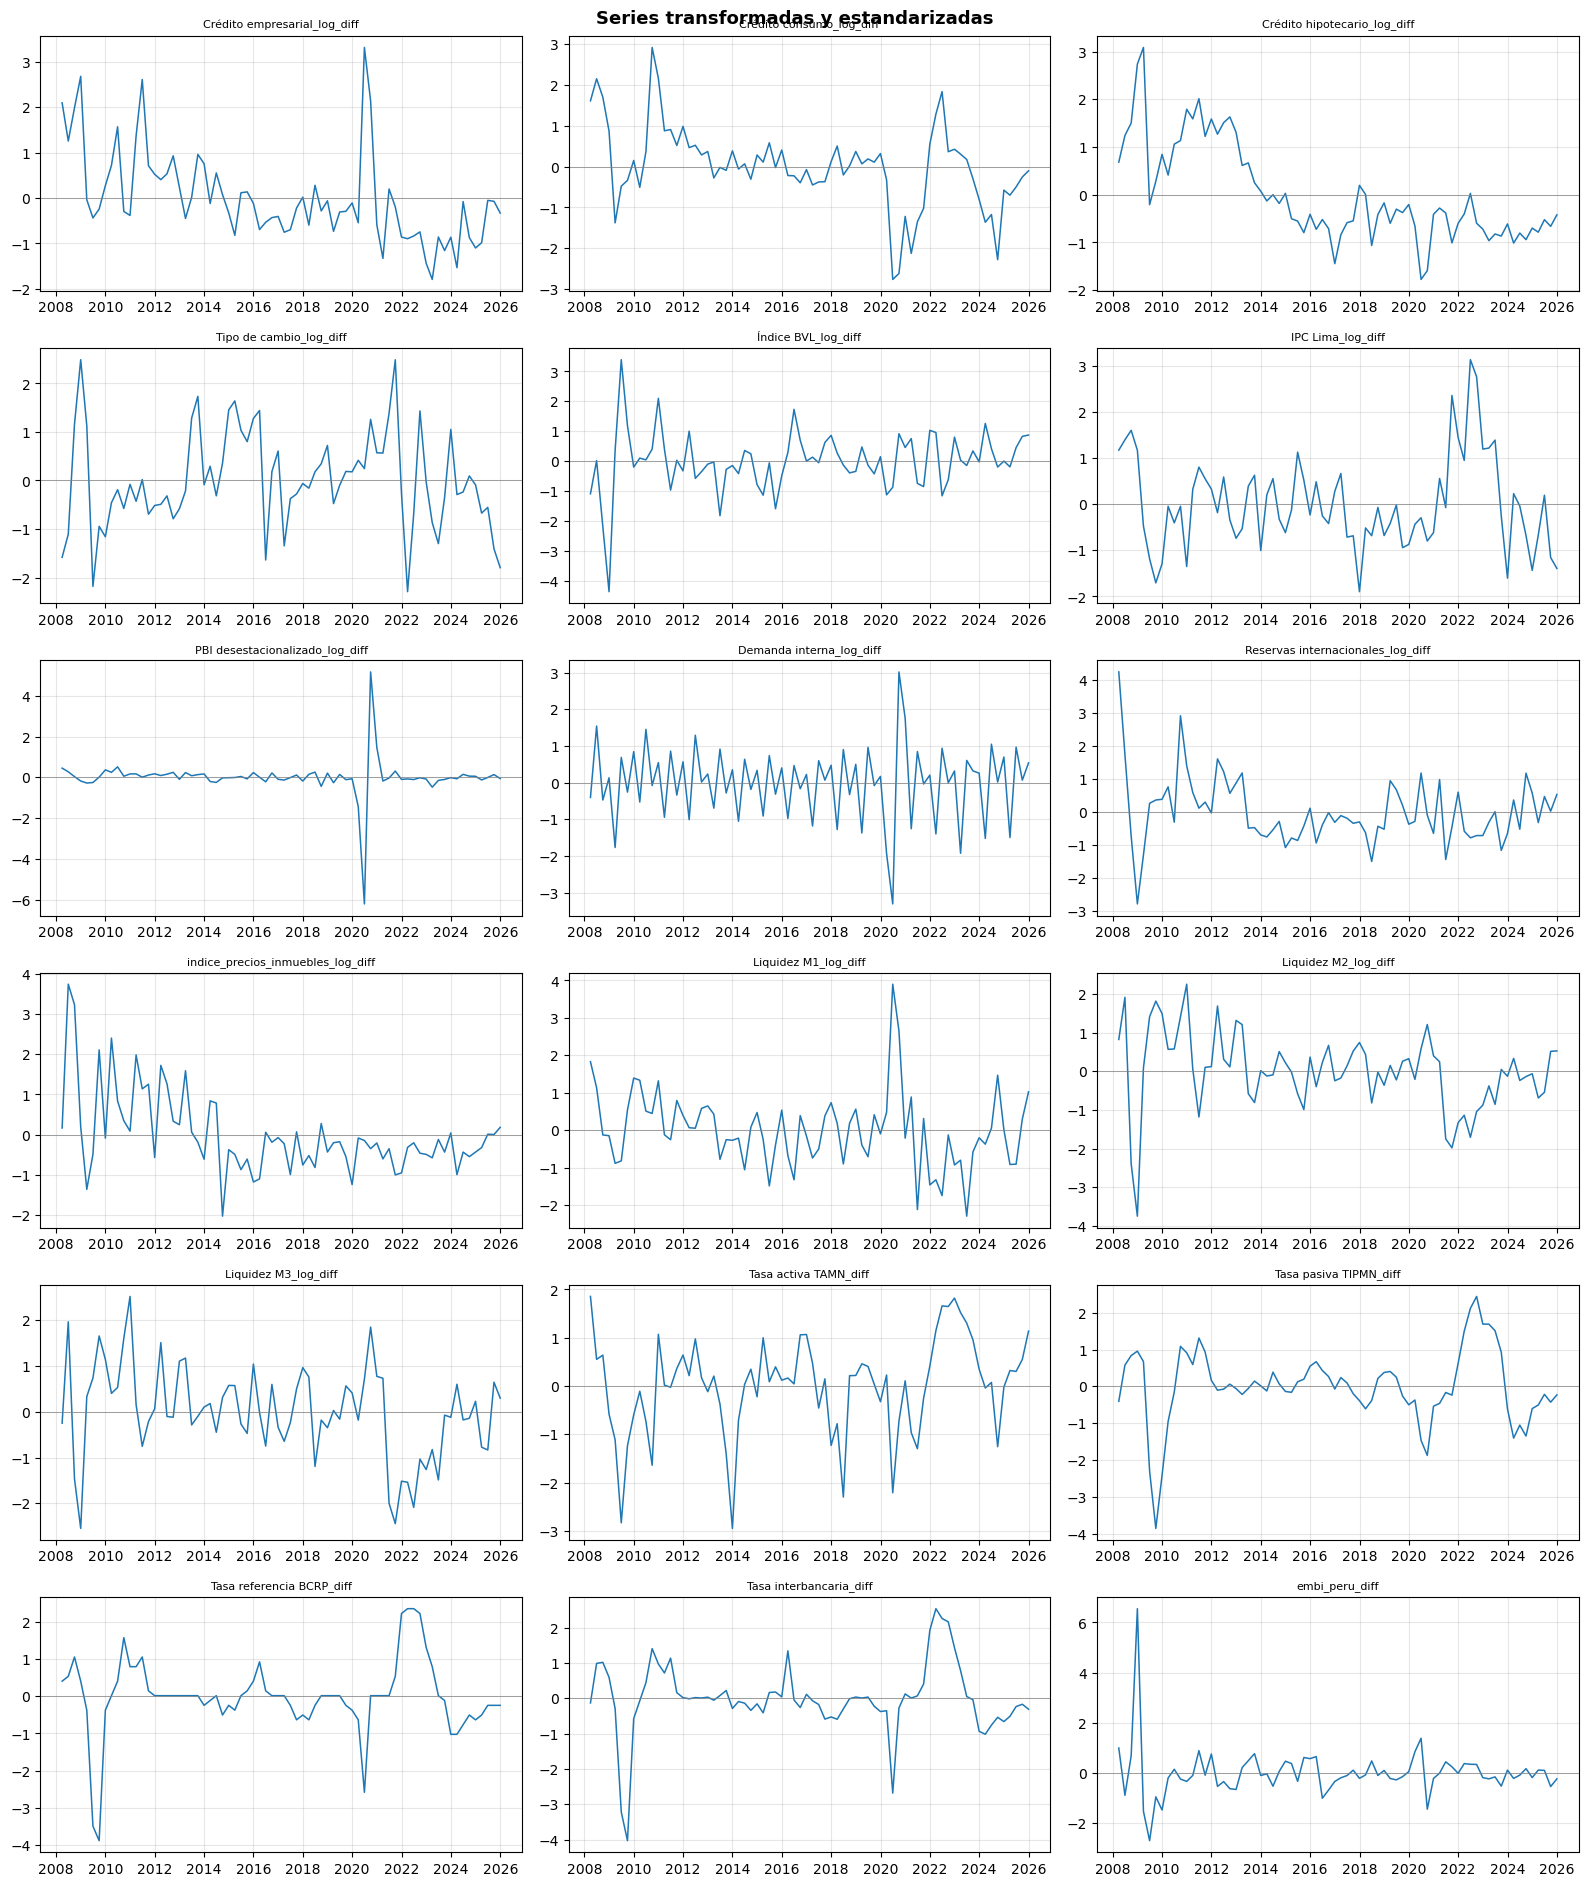

In [8]:
n_vars = len(df_estandarizado.columns)
n_cols = 3
n_rows = int(np.ceil(n_vars / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.2 * n_rows))
axes = axes.flatten()

for i, col in enumerate(df_estandarizado.columns):
    axes[i].plot(df_estandarizado.index, df_estandarizado[col], linewidth=1.1)
    axes[i].set_title(col, fontsize=8)
    axes[i].grid(True, alpha=0.3)
    axes[i].axhline(0, color='gray', linewidth=0.5)

for j in range(n_vars, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Series transformadas y estandarizadas', fontsize=13, fontweight='bold')
plt.tight_layout()
os.makedirs('reports/figures', exist_ok=True)
plt.savefig('reports/figures/04_series_estandarizadas.png', dpi=150, bbox_inches='tight')
print('Gráfico guardado')
plt.show()

## 8. Guardar los cuatro datasets derivados

Se guardan las cuatro versiones para trazabilidad y para poder comparar
PCA/HFC sobre niveles vs. sobre la versión transformada; ninguna
sobrescribe `data/raw/series_bcrp_raw.csv`.

In [9]:
os.makedirs('data/processed', exist_ok=True)

df_limpio.to_csv('data/processed/dataset_niveles_trimestral.csv')
df_niveles_estandarizado.to_csv('data/processed/dataset_niveles_estandarizado_trimestral.csv')
df_transformado.to_csv('data/processed/dataset_transformado_trimestral.csv')
df_estandarizado.to_csv('data/processed/dataset_estandarizado_trimestral.csv')

print('Datasets guardados en data/processed/:')
print('  - dataset_niveles_trimestral.csv                (niveles, solo sincronizado)')
print('  - dataset_niveles_estandarizado_trimestral.csv   (niveles + estandarizado, SIN transformar)')
print('  - dataset_transformado_trimestral.csv            (estacionario, sin estandarizar)')
print('  - dataset_estandarizado_trimestral.csv           (transformado + estandarizado, listo para PCA/HFC)')
print(f'\nDimensiones niveles (estandarizado): {df_niveles_estandarizado.shape[0]} trimestres x {df_niveles_estandarizado.shape[1]} variables')
print(f'Dimensiones transformado (estandarizado): {df_estandarizado.shape[0]} trimestres x {df_estandarizado.shape[1]} variables')
print()
print('El siguiente notebook (05_pca_hfc.ipynb) puede correr sobre ambas versiones')
print('estandarizadas para comparar resultados de niveles vs. transformado.')

Datasets guardados en data/processed/:
  - dataset_niveles_trimestral.csv                (niveles, solo sincronizado)
  - dataset_niveles_estandarizado_trimestral.csv   (niveles + estandarizado, SIN transformar)
  - dataset_transformado_trimestral.csv            (estacionario, sin estandarizar)
  - dataset_estandarizado_trimestral.csv           (transformado + estandarizado, listo para PCA/HFC)

Dimensiones niveles (estandarizado): 73 trimestres x 20 variables
Dimensiones transformado (estandarizado): 72 trimestres x 18 variables

El siguiente notebook (05_pca_hfc.ipynb) puede correr sobre ambas versiones
estandarizadas para comparar resultados de niveles vs. transformado.
